# Istanbul Shopping Mall Analytics

This notebook looks at the Istanbul shopping dataset from several angles at once: category, mall, payment method, gender and time. The main goal is to see where revenue is concentrated and whether the same patterns hold across different customer and mall segments.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

csv_path = Path("customer_shopping_data.csv")

if not csv_path.exists():
    desktop_file = Path.home() / "Desktop" / "customer_shopping_data.csv"
    csv_path = desktop_file if desktop_file.exists() else Path("/mnt/data/customer_shopping_data.csv")

df = pd.read_csv(csv_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 99,457
Columns: 10


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


## Quick check and preparation

I checked the basic data quality first, then prepared the date fields for the time analysis. In this dataset, `price` already represents the transaction amount for the purchased quantity, so I use it directly as revenue instead of multiplying it by `quantity` again.

In [2]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

quality_check = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique_values": df.nunique()
})

display(quality_check)

df["invoice_date"] = pd.to_datetime(df["invoice_date"], dayfirst=True)
df["year"] = df["invoice_date"].dt.year
df["month"] = df["invoice_date"].dt.month
df["month_period"] = df["invoice_date"].dt.to_period("M")
df["revenue"] = df["price"]

print("Date range:", df["invoice_date"].min().date(), "to", df["invoice_date"].max().date())

Missing values: 0
Duplicate rows: 0


,dtype,missing,unique_values
invoice_no,object,0,99457
customer_id,object,0,99457
gender,object,0,2
age,int64,0,52
category,object,0,8
quantity,int64,0,5
price,float64,0,40
payment_method,object,0,3
invoice_date,object,0,797
shopping_mall,object,0,10


Date range: 2021-01-01 to 2023-03-08


## Where the money comes from

I compared category, mall, payment method and gender using both transaction count and revenue. I also calculated average purchase value by category, since high-volume and high-value categories can tell very different stories.

In [3]:
category_summary = df.groupby("category").agg(
    transactions=("invoice_no", "count"),
    units_sold=("quantity", "sum"),
    revenue=("revenue", "sum"),
    avg_purchase=("revenue", "mean")
).sort_values("revenue", ascending=False)

mall_summary = df.groupby("shopping_mall").agg(
    transactions=("invoice_no", "count"),
    revenue=("revenue", "sum"),
    avg_purchase=("revenue", "mean")
).sort_values("revenue", ascending=False)

payment_summary = df.groupby("payment_method").agg(
    transactions=("invoice_no", "count"),
    revenue=("revenue", "sum")
).sort_values("revenue", ascending=False)

gender_summary = df.groupby("gender").agg(
    transactions=("invoice_no", "count"),
    revenue=("revenue", "sum"),
    avg_purchase=("revenue", "mean")
).sort_values("revenue", ascending=False)

print("CATEGORY")
display(category_summary.round(2))

print("\nSHOPPING MALL")
display(mall_summary.round(2))

print("\nPAYMENT METHOD")
display(payment_summary.round(2))

print("\nGENDER")
display(gender_summary.round(2))

CATEGORY


,transactions,units_sold,revenue,avg_purchase
category,,,,
Clothing,34487,103558,31075684.64,901.08
Shoes,10034,30217,18135336.89,1807.39
Technology,4996,15021,15772050.00,3156.94
Cosmetics,15097,45465,1848606.90,122.45
Toys,10087,30321,1086704.64,107.73
Food & Beverage,14776,44277,231568.71,15.67
Books,4981,14982,226977.30,45.57
Souvenir,4999,14871,174436.83,34.89



SHOPPING MALL


,transactions,revenue,avg_purchase
shopping_mall,,,
Mall of Istanbul,19943,13851737.62,694.57
Kanyon,19823,13710755.24,691.66
Metrocity,15011,10249980.07,682.83
Metropol AVM,10161,6937992.99,682.81
Istinye Park,9781,6717077.54,686.75
Zorlu Center,5075,3509649.02,691.56
Cevahir AVM,4991,3433671.84,687.97
Viaport Outlet,4914,3414019.46,694.75
Emaar Square Mall,4811,3390408.31,704.72



PAYMENT METHOD


,transactions,revenue
payment_method,,
Cash,44447,30705030.98
Credit Card,34931,24051476.93
Debit Card,20079,13794858.00



GENDER


,transactions,revenue,avg_purchase
gender,,,
Female,59482,40931801.62,688.14
Male,39975,27619564.29,690.92


## Mall × category revenue

The pivot table is the core multi-dimensional view here. It shows whether the strongest categories are spread evenly across malls or whether some locations depend more heavily on particular product groups.

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
shopping_mall,,,,,,,,
Cevahir AVM,11998.80,1554414.40,88394.84,11992.39,884050.41,8304.84,819000.0,55516.16
Emaar Square Mall,11059.50,1511803.04,92379.52,11030.07,871446.84,8515.98,834750.0,49423.36
Forum Istanbul,11453.40,1572119.12,95225.72,10836.56,875648.03,9090.75,706650.0,55050.24
Istinye Park,20725.20,3050313.20,178741.36,23419.94,1806511.70,18369.18,1509900.0,109096.96
Kanyon,44980.35,6155541.04,372242.30,45474.85,3640031.05,35483.25,3202500.0,214502.40
Mall of Istanbul,46949.85,6245565.04,373787.38,46431.94,3668239.04,34263.33,3220350.0,216151.04
Metrocity,34405.65,4719958.32,272422.00,35375.72,2610139.33,25770.81,2386650.0,165258.24
Metropol AVM,22240.20,3166444.16,185775.54,23984.78,1942750.29,18603.78,1465800.0,112394.24
Viaport Outlet,10908.00,1530708.08,92664.14,11432.78,882850.07,7636.23,823200.0,54620.16


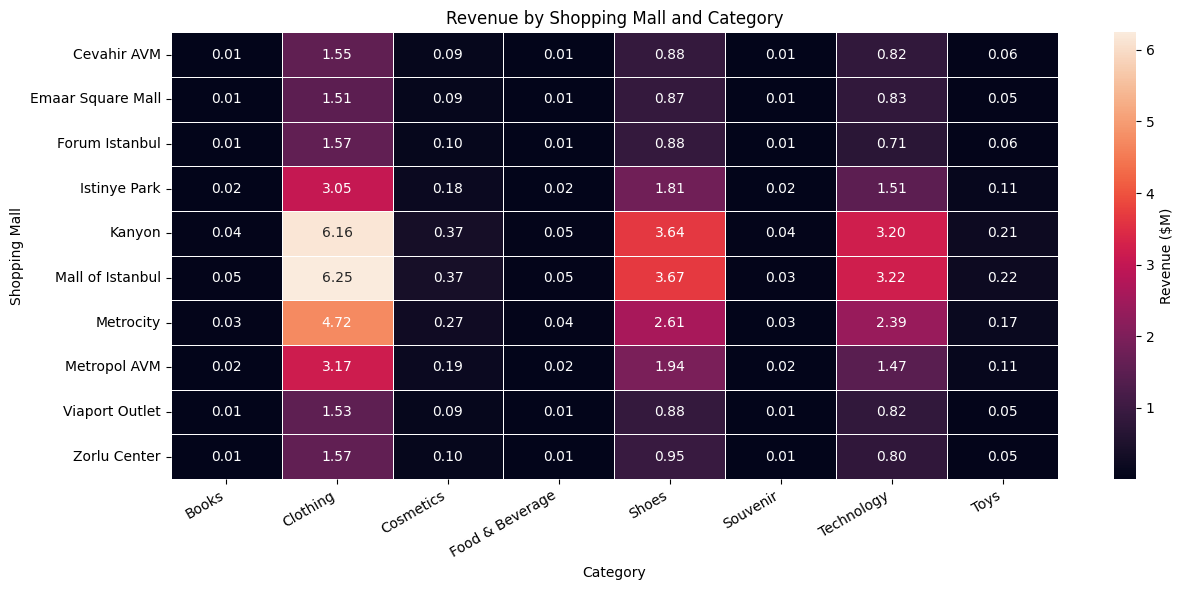

In [4]:
mall_category = pd.pivot_table(
    df,
    index="shopping_mall",
    columns="category",
    values="revenue",
    aggfunc="sum",
    fill_value=0
)

display(mall_category.round(2))

# values are shown in millions so the heatmap stays readable
mall_category_m = mall_category / 1_000_000

plt.figure(figsize=(13, 6))
sns.heatmap(
    mall_category_m,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Revenue ($M)"}
)
plt.title("Revenue by Shopping Mall and Category")
plt.xlabel("Category")
plt.ylabel("Shopping Mall")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Yearly category trend

Next I compared 2021, 2022 and 2023 revenue by category. One thing to keep in mind is that the dataset only runs through early March 2023, so the last year is partial and should not be treated like a full-year decline.

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
year,,,,,,,,
2021,100065.75,14365129.68,828081.56,106179.46,8242134.61,79118.85,7104300.0,491294.72
2022,106822.65,14070451.12,855405.08,105876.12,8378373.20,80948.73,7268100.0,506849.28
2023,20088.90,2640103.84,165120.26,19513.13,1514829.08,14369.25,1399650.0,88560.64


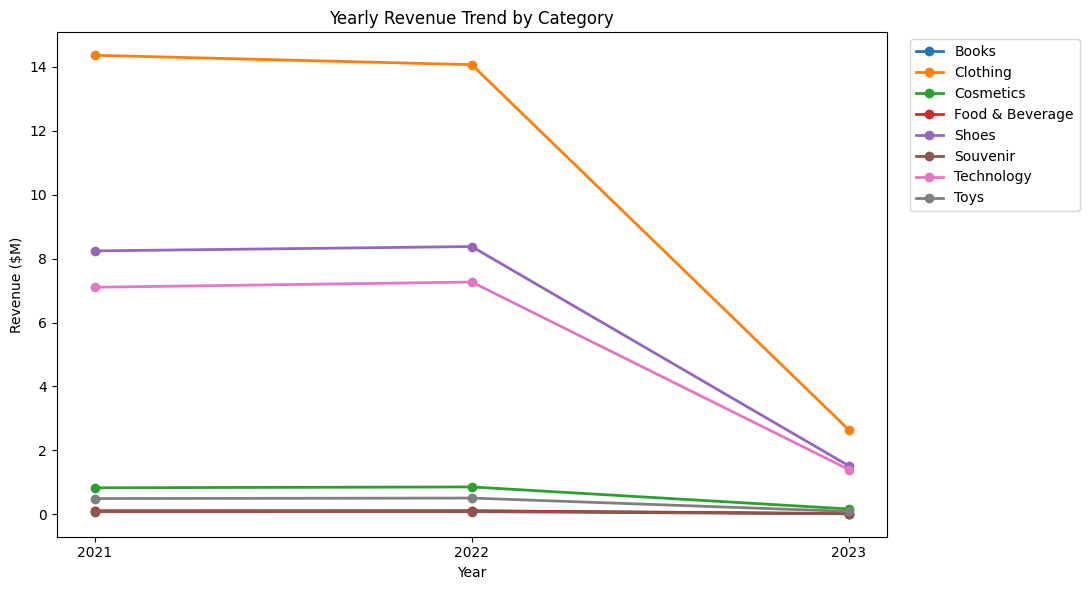

In [5]:
yearly_category = pd.pivot_table(
    df,
    index="year",
    columns="category",
    values="revenue",
    aggfunc="sum",
    fill_value=0
)

display(yearly_category.round(2))

plt.figure(figsize=(11, 6))

for category in yearly_category.columns:
    plt.plot(
        yearly_category.index,
        yearly_category[category] / 1_000_000,
        marker="o",
        linewidth=2,
        label=category
    )

plt.title("Yearly Revenue Trend by Category")
plt.xlabel("Year")
plt.ylabel("Revenue ($M)")
plt.xticks([2021, 2022, 2023])
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Female vs male spending

This comparison focuses on total spending by category, not just customer counts. It helps separate categories that are popular overall from categories where one customer group contributes more revenue.

gender,Female,Male
category,,
Clothing,18616663.12,12459021.52
Shoes,10746644.02,7388692.87
Technology,9425850.00,6346200.00
Cosmetics,1108432.26,740174.64
Toys,658094.08,428610.56
Food & Beverage,137873.26,93695.45
Books,132956.40,94020.90
Souvenir,105288.48,69148.35


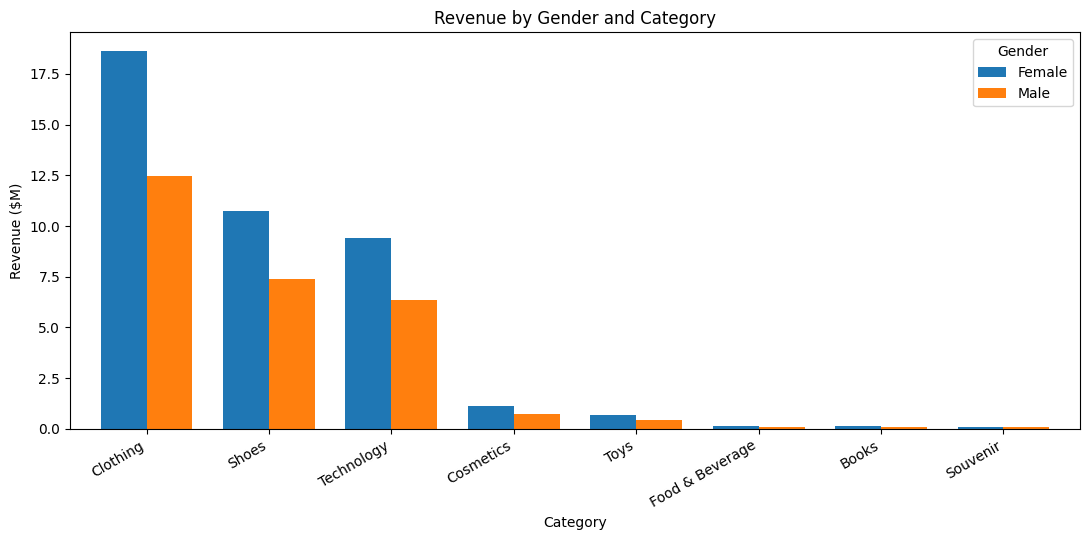

In [6]:
gender_category = pd.pivot_table(
    df,
    index="category",
    columns="gender",
    values="revenue",
    aggfunc="sum",
    fill_value=0
)

gender_category = gender_category.sort_values(
    gender_category.columns.tolist(),
    ascending=False
)

display(gender_category.round(2))

ax = (gender_category / 1_000_000).plot(
    kind="bar",
    figsize=(11, 5.5),
    width=0.75
)

ax.set_title("Revenue by Gender and Category")
ax.set_xlabel("Category")
ax.set_ylabel("Revenue ($M)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## Bonus checks

I added two extra views from the optional section: month-over-month revenue growth for each mall, and the dominant payment method inside every category. For the payment mix, I also plotted category-level shares so the result is easier to compare than a plain count table.

MONTH-OVER-MONTH REVENUE GROWTH (%)


shopping_mall,Cevahir AVM,Emaar Square Mall,Forum Istanbul,Istinye Park,Kanyon,Mall of Istanbul,Metrocity,Metropol AVM,Viaport Outlet,Zorlu Center
month_period,,,,,,,,,,
2021-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-02,-30.4,-9.1,-21.9,-18.9,-14.2,-11.8,5.9,7.0,-12.9,-27.8
2021-03,55.9,27.2,2.2,8.3,14.0,-6.4,13.7,10.2,13.7,35.2
2021-04,-17.5,-5.4,46.4,0.8,-9.9,8.4,-16.2,-11.3,19.8,7.7
2021-05,11.1,11.9,-4.8,4.1,4.9,2.6,7.2,9.3,0.8,-11.1
2021-06,-12.9,-15.0,-15.9,-3.5,-7.0,-1.5,4.7,-0.8,-19.4,11.9
2021-07,25.9,44.6,9.6,35.4,9.5,-0.2,7.7,-14.7,25.2,7.7
2021-08,-17.3,-34.8,-24.6,-26.5,3.2,0.3,1.7,17.5,-2.4,-18.2
2021-09,12.9,24.5,3.4,-0.6,-5.8,-6.7,-10.5,-3.4,-26.2,9.3



DOMINANT PAYMENT METHOD BY CATEGORY


,dominant_method,share_pct
category,,
Books,Cash,45.5
Toys,Cash,45.0
Clothing,Cash,44.8
Technology,Cash,44.7
Shoes,Cash,44.6
Food & Beverage,Cash,44.6
Souvenir,Cash,44.2
Cosmetics,Cash,44.2


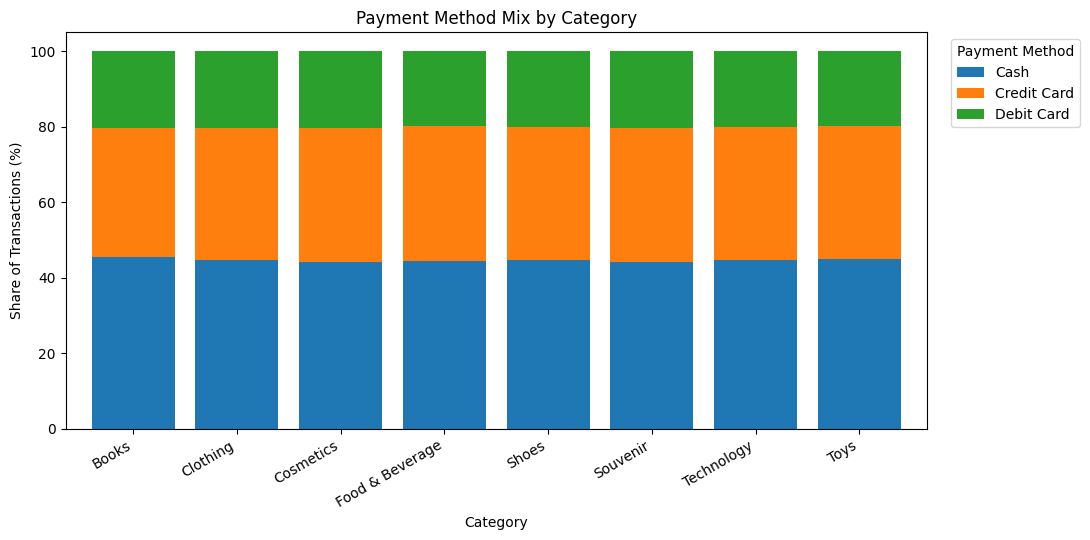

In [7]:
monthly_mall = df.groupby(["shopping_mall", "month_period"])["revenue"].sum().reset_index()
monthly_mall["mom_growth_pct"] = monthly_mall.groupby("shopping_mall")["revenue"].pct_change() * 100

mom_growth_table = monthly_mall.pivot(
    index="month_period",
    columns="shopping_mall",
    values="mom_growth_pct"
)

print("MONTH-OVER-MONTH REVENUE GROWTH (%)")
display(mom_growth_table.round(1))

payment_category = df.groupby(["category", "payment_method"]).size().unstack(fill_value=0)
payment_share = payment_category.div(payment_category.sum(axis=1), axis=0) * 100

dominant_payment = pd.DataFrame({
    "dominant_method": payment_category.idxmax(axis=1),
    "share_pct": payment_share.max(axis=1)
}).sort_values("share_pct", ascending=False)

print("\nDOMINANT PAYMENT METHOD BY CATEGORY")
display(dominant_payment.round(1))

ax = payment_share.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 5.5),
    width=0.8
)

ax.set_title("Payment Method Mix by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Share of Transactions (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Payment Method", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Business takeaways

1. **Clothing is the biggest revenue engine.** It accounts for about **45% of total revenue** and more than **103K units sold**. Mall managers should protect availability in this category, especially in the highest-volume locations, while avoiding over-reliance on one segment.

2. **Mall of Istanbul and Kanyon together generate roughly 40% of total revenue.** They are strong candidates for testing promotions or merchandising changes first. At the same time, **Emaar Square Mall has the highest average purchase value**, so its growth opportunity may be more about increasing traffic than increasing basket size.

3. **Female customers contribute close to 60% of revenue across every major category**, but average purchase value is almost the same for men and women. The difference is mainly transaction volume, which makes female retention important while leaving room to grow male visit frequency.

4. **Cash is the leading payment method in every category**, usually around the mid-40% range. Credit card usage is still substantial, so category-specific card offers could be tested without designing the payment experience around only one method.

5. **2022 revenue is only slightly above 2021, while 2023 is incomplete.** Management should avoid reading the lower 2023 total as a downturn. Monthly growth by mall is quite volatile, so same-month year-over-year comparisons would be safer for future performance tracking.